### Contexto
Breve explicação de qual é o problema e o que buscamos resolver.

### Imports
Explicar quais bibliotecas estamos usando e o porquê.

### Exploração dos dados
Etapa para analisar as principais características de um conjunto de dados, identificando padrões, tendências e anomalias.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [5]:
!pip install openpyxl

In [13]:
url = "https://raw.githubusercontent.com/AnaElisaMueller/rna/main/data/healthcare_fraud_detection_v1.xlsx"
df = pd.read_excel(url)

In [14]:
df.describe()

,É Fraude,Idade do Paciente,Código do Procedimento,Valor da Solicitação,Valor Aprovado,Data de Envio da Solicitação,Dias Entre o Atendimento e a Solicitação,Número de Solicitações por Prestador (Mensal),Unnamed: 14,Tempo de Internação,Indicador de Condição Crônica,Visitas Anteriores nos Últimos 12 Meses
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000,10000.000000,10000.000000,0.0,10000.00000,10000.000000,9650.000000
mean,0.082900,49.755000,86905.21170,572.804406,475.514157,2023-01-10 02:13:12,14.413800,68.628000,NaN,2.19930,0.292000,3.026425
min,0.000000,1.000000,36415.00000,60.210000,50.350000,2021-01-06 00:00:00,0.000000,42.000000,NaN,0.00000,0.000000,0.000000
25%,0.000000,37.750000,80053.00000,305.205000,257.200000,2022-01-13 00:00:00,7.000000,60.000000,NaN,1.00000,0.000000,2.000000
50%,0.000000,50.000000,93000.00000,461.225000,388.370000,2023-01-03 00:00:00,14.000000,66.000000,NaN,2.00000,0.000000,3.000000
75%,0.000000,62.000000,99213.00000,711.365000,598.347500,2024-01-05 00:00:00,22.000000,72.000000,NaN,3.00000,1.000000,4.000000
max,1.000000,95.000000,99214.00000,6590.700000,4270.890000,2025-01-26 00:00:00,29.000000,144.000000,NaN,5.00000,1.000000,12.000000
std,0.275745,17.910144,14965.32496,406.202437,323.257165,NaN,8.489875,14.905872,NaN,1.71046,0.454705,1.722789


In [15]:
#Remoção de coluna vazia
df = df.drop(columns=['Unnamed: 14'])

In [17]:
#Verificação de nulos por coluna

print("Número de valores nulos por coluna:")
display(df.isnull().sum())

print("Total de valores nulos no DataFrame:")
print(df.isnull().sum().sum())

Número de valores nulos por coluna:


,0
É Fraude,0
Idade do Paciente,0
Gênero do Paciente,0
Código de Diagnóstico,0
Código do Procedimento,0
Valor da Solicitação,0
Valor Aprovado,0
Tipo de Seguro,350
Data de Envio da Solicitação,0
Dias Entre o Atendimento e a Solicitação,0


Total de valores nulos no DataFrame:
1050


#####Exploração dos valores possíveis em colunas categóricas

In [20]:
distinct_specialties = df['Especialidade do Prestador'].unique().copy()
print("Valores distintos da coluna 'Especialidade do Prestador':")
distinct_specialties

Valores distintos da coluna 'Especialidade do Prestador':


array(['Cardiology', 'General Practice', 'Pulmonology', 'Orthopedics',
       nan, 'Internal Medicine', 'Neurology'], dtype=object)

In [19]:
tipo_seguro = df['Tipo de Seguro'].unique().copy()
print("Valores distintos da coluna 'Tipo de Seguro':")
tipo_seguro

Valores distintos da coluna 'Tipo de Seguro':


array(['Medicaid', 'Self-Pay', 'Private', 'Medicare', nan], dtype=object)

#####Contagem agrupada para posterior tratamento de nulos

In [21]:
count_tipo_seguro = df['Tipo de Seguro'].value_counts().copy()
print("Contagem de valores distintos da coluna 'Tipo de Seguro':")
count_tipo_seguro

Contagem de valores distintos da coluna 'Tipo de Seguro':


,count
Tipo de Seguro,
Medicare,2425
Medicaid,2419
Private,2405
Self-Pay,2401


In [22]:
count_especialidades = df['Especialidade do Prestador'].value_counts().copy()
print("Contagem de valores distintos da coluna 'Especialidade do Prestador':")
count_especialidades

Contagem de valores distintos da coluna 'Especialidade do Prestador':


,count
Especialidade do Prestador,
Internal Medicine,2019
General Practice,1878
Orthopedics,1616
Neurology,1516
Cardiology,1366
Pulmonology,1255


In [ ]:
df_nulls = df[df.isnull().any(axis=1)]
df_nulls

Verificação de compatibilidade de casos em que a coluna ['Visitas Anteriores nos  Últimos 12 Meses'] foi preenchida com 0 e de quando não foi preenchida.

In [25]:
import pandas as pd
import numpy as np


# Isso vai dividir o dataset em três grupos: quem tem 0, quem tem NaN e quem tem 1 ou mais visitas.
condicoes = [
    df['Visitas Anteriores nos Últimos 12 Meses'] == 0,
    df['Visitas Anteriores nos Últimos 12 Meses'].isna(),
    df['Visitas Anteriores nos Últimos 12 Meses'] > 0
]
valores = ['Grupo_Zero', 'Grupo_NaN', 'Grupo_Com_Visitas']

df['Grupo_Analise'] = np.select(condicoes, valores, default='Outros')

# 2. Avaliar variáveis numéricas (Idade, Tempo de Internação, etc.)
print("--- Média de Idade e Tempo de Internação por Grupo ---")
analise_numerica = df.groupby('Grupo_Analise')[['Idade do Paciente', 'Tempo de Internação']].mean()
print(analise_numerica)
print("\n" + "="*50 + "\n")

# 3. Avaliar variáveis categóricas cruciais (Condição Crônica e Tipo de Visita)
print("--- Proporção de Condições Crônicas por Grupo (%) ---")
# Mostra a porcentagem de pacientes com condição crônica dentro de cada grupo
cronicos_por_grupo = pd.crosstab(df['Grupo_Analise'], df['Indicador de Condição Crônica'], normalize='index') * 100
print(cronicos_por_grupo)
print("\n" + "="*50 + "\n")

print("--- Distribuição do Tipo de Visita por Grupo (%) ---")
visita_por_grupo = pd.crosstab(df['Grupo_Analise'], df['Tipo de Visita'], normalize='index') * 100
print(visita_por_grupo)

# Limpeza da coluna temporária após a análise
df.drop(columns=['Grupo_Analise'], inplace=True)

--- Média de Idade e Tempo de Internação por Grupo ---
                   Idade do Paciente  Tempo de Internação
Grupo_Analise                                            
Grupo_Com_Visitas          49.754189             2.198150
Grupo_NaN                  49.640000             2.302857
Grupo_Zero                 49.858696             2.143478


--- Proporção de Condições Crônicas por Grupo (%) ---
Indicador de Condição Crônica          0          1
Grupo_Analise                                      
Grupo_Com_Visitas              70.794342  29.205658
Grupo_NaN                      70.571429  29.428571
Grupo_Zero                     71.086957  28.913043


--- Distribuição do Tipo de Visita por Grupo (%) ---
Tipo de Visita     Emergency  Inpatient  Outpatient
Grupo_Analise                                      
Grupo_Com_Visitas  33.710555  32.132753   34.156692
Grupo_NaN          32.857143  31.142857   36.000000
Grupo_Zero         33.695652  31.956522   34.347826


/tmp/ipykernel_9063/523915814.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=analise_numerica, x='Grupo Analise', y='Idade do Paciente', ax=axes[0, 0], palette='Blues_r', order=ordem_presente)
/tmp/ipykernel_9063/523915814.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=analise_numerica, x='Grupo Analise', y='Tempo de Internação', ax=axes[0, 1], palette='Oranges_r', order=ordem_presente)


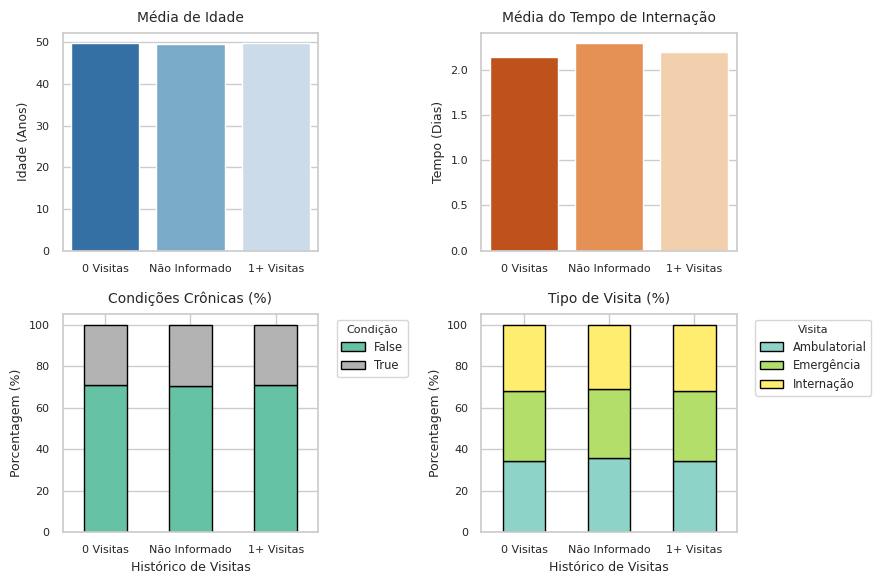

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Criação dos grupos com nomes amigáveis (sem underscores)
condicoes = [
    df['Visitas Anteriores nos Últimos 12 Meses'] == 0,
    df['Visitas Anteriores nos Últimos 12 Meses'].isna(),
    df['Visitas Anteriores nos Últimos 12 Meses'] > 0
]

# ---> ALTERAÇÃO AQUI: Nomes limpos para o eixo X <---
valores = ['0 Visitas', 'Não Informado', '1+ Visitas']

df['Grupo Analise'] = np.select(condicoes, valores, default='Outros')

# Configuração de estilo visual para os gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# ---------------------------------------------------------
# Gráfico 1: Média de Idade por Grupo
# ---------------------------------------------------------
analise_numerica = df.groupby('Grupo Analise')[['Idade do Paciente', 'Tempo de Internação']].mean().reset_index()

# Garantir a ordem lógica no gráfico
ordem_grupos = ['0 Visitas', 'Não Informado', '1+ Visitas', 'Outros']
ordem_presente = [g for g in ordem_grupos if g in analise_numerica['Grupo Analise'].values]

sns.barplot(data=analise_numerica, x='Grupo Analise', y='Idade do Paciente', ax=axes[0, 0], palette='Blues_r', order=ordem_presente)
axes[0, 0].set_title('Média de Idade', fontsize=10, pad=8)
axes[0, 0].set_ylabel('Idade (Anos)', fontsize=9)
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(labelsize=8)

# ---------------------------------------------------------
# Gráfico 2: Média do Tempo de Internação por Grupo
# ---------------------------------------------------------
sns.barplot(data=analise_numerica, x='Grupo Analise', y='Tempo de Internação', ax=axes[0, 1], palette='Oranges_r', order=ordem_presente)
axes[0, 1].set_title('Média do Tempo de Internação', fontsize=10, pad=8)
axes[0, 1].set_ylabel('Tempo (Dias)', fontsize=9)
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(labelsize=8)

# ---------------------------------------------------------
# Gráfico 3: Proporção de Condições Crônicas (Barras Empilhadas)
# ---------------------------------------------------------
cronicos_por_grupo = pd.crosstab(df['Grupo Analise'], df['Indicador de Condição Crônica'], normalize='index') * 100
# Reordenar as linhas para manter a consistência visual
cronicos_por_grupo = cronicos_por_grupo.reindex(ordem_presente)

cronicos_por_grupo.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap='Set2', edgecolor='black')

axes[1, 0].set_title('Condições Crônicas (%)', fontsize=10, pad=8)
axes[1, 0].set_ylabel('Porcentagem (%)', fontsize=9)
axes[1, 0].set_xlabel('Histórico de Visitas', fontsize=9)
axes[1, 0].tick_params(axis='x', rotation=0, labelsize=8) # Rotação em 0 pois os nomes agora são mais curtos
axes[1, 0].tick_params(axis='y', labelsize=8)
axes[1, 0].legend(title='Condição', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small', title_fontsize='8')

# ---------------------------------------------------------
# Gráfico 4: Distribuição do Tipo de Visita (Barras Empilhadas)
# ---------------------------------------------------------
visita_por_grupo = pd.crosstab(df['Grupo Analise'], df['Tipo de Visita'], normalize='index') * 100
visita_por_grupo = visita_por_grupo.reindex(ordem_presente)

visita_por_grupo.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='Set3', edgecolor='black')

axes[1, 1].set_title('Tipo de Visita (%)', fontsize=10, pad=8)
axes[1, 1].set_ylabel('Porcentagem (%)', fontsize=9)
axes[1, 1].set_xlabel('Histórico de Visitas', fontsize=9)
axes[1, 1].tick_params(axis='x', rotation=0, labelsize=8)
axes[1, 1].tick_params(axis='y', labelsize=8)
axes[1, 1].legend(title='Visita', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small', title_fontsize='8')

# ---------------------------------------------------------
# Ajustes finais e plotagem
# ---------------------------------------------------------
plt.tight_layout()
plt.show()

# Limpeza da coluna temporária
df.drop(columns=['Grupo Analise'], inplace=True)

Conclusão: a quantidade de visitas é uma contagem totalmente aleatória, não possui relação com outros atributos do dataset. Mas é interessante observar também a destribuição média dos valores, indicando que possivelmente nosso dataset é artificial.

In [42]:
moda = df['Visitas Anteriores nos Últimos 12 Meses'].mode()[0]
print(f"A moda da coluna 'Visitas Anteriores nos Últimos 12 Meses' é: {moda}")

A moda da coluna 'Visitas Anteriores nos Últimos 12 Meses' é: 3.0


### Tratamento dos dados
Etapa para tratar nulos, padronizar, transformar de inglês para português.

In [29]:
#Transformação em saída booleana da coluna de Fraude
df['É Fraude'] = df['É Fraude'].astype(bool)

print("Valores únicos na coluna 'É Fraude' após padronização:")
display(df['É Fraude'].unique())

Valores únicos na coluna 'É Fraude' após padronização:


array([False,  True])

In [31]:
df['Indicador de Condição Crônica'] = df['Indicador de Condição Crônica'].astype(bool)

print("Valores únicos na coluna 'Indicador de Condição Crônica' após padronização:")
display(df['Indicador de Condição Crônica'].unique())

Valores únicos na coluna 'Indicador de Condição Crônica' após padronização:


array([ True, False])

In [30]:
df['Especialidade do Prestador'] = df['Especialidade do Prestador'].fillna('Não informado')

print("Valores únicos na coluna 'Especialidade do Prestador' após o preenchimento:")
display(df['Especialidade do Prestador'].unique())

Valores únicos na coluna 'Especialidade do Prestador' após o preenchimento:


array(['Cardiology', 'General Practice', 'Pulmonology', 'Orthopedics',
       'Não informado', 'Internal Medicine', 'Neurology'], dtype=object)

In [36]:
df['Tipo de Seguro'] = df['Tipo de Seguro'].fillna('Não informado')

print("Valores únicos na coluna 'Tipo de Seguro' após o preenchimento:")
display(df['Tipo de Seguro'].unique())

Valores únicos na coluna 'Tipo de Seguro' após o preenchimento:


array(['Medicaid', 'Pagamento Direto', 'Privado', 'Medicare',
       'Não informado'], dtype=object)

Tradução de valores para português

In [37]:
specialty_translation = {
    'Cardiology': 'Cardiologia',
    'General Practice': 'Clínica Geral',
    'Pulmonology': 'Pneumologia',
    'Orthopedics': 'Ortopedia',
    'Internal Medicine': 'Medicina Interna',
    'Neurology': 'Neurologia',
    'Não informado': 'Não informado' # Keep 'Não informado' as is
}

df['Especialidade do Prestador'] = df['Especialidade do Prestador'].map(specialty_translation)

print("Valores únicos na coluna 'Especialidade do Prestador' após a tradução:")
display(df['Especialidade do Prestador'].unique())

Valores únicos na coluna 'Especialidade do Prestador' após a tradução:


array(['Cardiologia', 'Clínica Geral', 'Pneumologia', 'Ortopedia',
       'Não informado', 'Medicina Interna', 'Neurologia'], dtype=object)

In [32]:
genero_traduzido = {
    'Male': 'Masculino',
    'Female': 'Feminino',
    # Se houverem valores nulos, eles podem ser mapeados para 'Não informado'
    None: 'Não informado',
    'nan': 'Não informado' # Em caso de NaN como string
}

df['Gênero do Paciente'] = df['Gênero do Paciente'].map(genero_traduzido).fillna('Não informado')

print("Valores únicos na coluna 'Gênero do Paciente' após a tradução:")
display(df['Gênero do Paciente'].unique())

Valores únicos na coluna 'Gênero do Paciente' após a tradução:


array(['Masculino', 'Feminino'], dtype=object)

In [33]:
visit_type_translation = {
    'Outpatient': 'Ambulatorial',
    'Emergency': 'Emergência',
    'Inpatient': 'Internação'
}

df['Tipo de Visita'] = df['Tipo de Visita'].map(visit_type_translation)

print("Valores únicos na coluna 'Tipo de Visita' após a tradução:")
display(df['Tipo de Visita'].unique())

Valores únicos na coluna 'Tipo de Visita' após a tradução:


array(['Ambulatorial', 'Internação', 'Emergência'], dtype=object)

In [34]:
insurance_type_translation = {
    'Medicaid': 'Medicaid',
    'Self-Pay': 'Pagamento Direto',
    'Private': 'Privado',
    'Medicare': 'Medicare'
}

df['Tipo de Seguro'] = df['Tipo de Seguro'].map(insurance_type_translation)

print("Valores únicos na coluna 'Tipo de Seguro' após a tradução:")
display(df['Tipo de Seguro'].unique())

Valores únicos na coluna 'Tipo de Seguro' após a tradução:


array(['Medicaid', 'Pagamento Direto', 'Privado', 'Medicare', nan],
      dtype=object)

In [35]:
status_solicitacao_translation = {
    'Approved': 'Aprovado',
    'Pending': 'Pendente',
    'Rejected': 'Rejeitado'
}

df['Status da Solicitação'] = df['Status da Solicitação'].map(status_solicitacao_translation)

print("Valores únicos na coluna 'Status da Solicitação' após a tradução:")
display(df['Status da Solicitação'].unique())

Valores únicos na coluna 'Status da Solicitação' após a tradução:


array(['Aprovado', 'Pendente', 'Rejeitado'], dtype=object)

Pelo fato dos valores faltantes de ['Visitas Anteriores nos Últimos 12 Meses'] representarem menos de 5% do dataset, a melhor prática nesse caso foi excluir as linhas nulas.

In [43]:
df.dropna(subset=['Visitas Anteriores nos Últimos 12 Meses'], inplace=True)

In [44]:
#Verificação de nulos por coluna

print("Número de valores nulos por coluna:")
display(df.isnull().sum())

print("Total de valores nulos no DataFrame:")
#print(df.isnull().sum().sum())

Número de valores nulos por coluna:


,0
É Fraude,0
Idade do Paciente,0
Gênero do Paciente,0
Código de Diagnóstico,0
Código do Procedimento,0
Valor da Solicitação,0
Valor Aprovado,0
Tipo de Seguro,0
Data de Envio da Solicitação,0
Dias Entre o Atendimento e a Solicitação,0


Total de valores nulos no DataFrame:
0


In [50]:
#Padranização de tipos
tipos_dados = {
    'É Fraude': 'boolean',
    'Indicador de Condição Crônica': 'boolean',
    'Código de Diagnóstico': 'string',
    'Idade do Paciente': 'int8',
    'Tempo de Internação': 'int8',
    'Visitas Anteriores nos Últimos 12 Meses': 'int16',
    'Gênero do Paciente': 'category',
    'Especialidade do Prestador': 'category',
    'Tipo de Visita': 'category',
    'Tipo de Seguro': 'category',
    'Status da Solicitação': 'category'
}

df = df.astype(tipos_dados)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9650 entries, 0 to 9998
Data columns (total 18 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   É Fraude                                       9650 non-null   boolean       
 1   Idade do Paciente                              9650 non-null   int8          
 2   Gênero do Paciente                             9650 non-null   category      
 3   Código de Diagnóstico                          9650 non-null   string        
 4   Código do Procedimento                         9650 non-null   int64         
 5   Valor da Solicitação                           9650 non-null   float64       
 6   Valor Aprovado                                 9650 non-null   float64       
 7   Tipo de Seguro                                 9650 non-null   category      
 8   Data de Envio da Solicitação                   9650 non-null   

In [45]:
df.to_excel('dataset_tratado.xlsx', index=False)

### Separação treino/teste
Separar os dados em dois grupos: os que serão usados para treinamento e os que serão usados para teste.

Indicado: 80/20

### Criação, compilação e treinamento da RNA
Devemos mostrar "Número de iterações atingido no aprendizado" (épocas/epochs), "Taxa de aprendizado", "Número de camadas intermediárias" e "Neurônios das camadas intermediárias".

### Avaliação de Métricas
Explicar quais métricas escolhemos e o porquê.

Devemos mostrar o "Erro atingido no aprendizado".

### Testes com parâmetros
Esta seção apresenta experimentos realizados com diferentes configurações da rede neural. Podemos alterar quantidade de neurônios, número de camadas ocultas, taxa de aprendizado ou quantidade de épocas e comparar os resultados obtidos. O objetivo é demonstrar como os parâmetros influenciam o desempenho do modelo.

### Previsões
Aqui são realizados testes práticos utilizando entradas fornecidas manualmente ou exemplos do dataset. O modelo gera previsões para novos dados e vocês mostram os resultados obtidos pela RNA. Essa etapa ajuda a demonstrar o funcionamento da aplicação na prática.

Aqui vai a parte de "Valores dos padrões de entrada definidos pelos usuários (string de bits)" e de "Valores do padrão de saída reconhecido (string de bits)" solicitada pela professora.

### Conclusão
Aqui vai a análise final sobre os resultados alcançados, se o objetivo foi atingido, quais dificuldades foram encontradas, quais limitações o modelo apresentou e possíveis melhorias futuras.